# GRUM Paper Reproduction: Experimental Figures

> This notebook is organized by figure. Each section includes the command needed to rerun that figure's experiment when applicable.

## Figure Index

- Figure 1: Informative flowchart in the paper (not an experiment; no reproduction run needed).
- Figure 2: Social-choice asymptotic reproduction (implemented below).
- Figure 3+: Experimental figure sections to be added with run commands.

In [1]:
from __future__ import annotations

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    # If opened from another working directory, try notebook parent traversal
    for parent in Path.cwd().parents:
        if (parent / "configs").exists() and (parent / "scripts").exists():
            ROOT = parent
            break

RESULTS_REPRO_DIR = ROOT / "results/repro"

# Set this explicitly for deterministic presentation runs, e.g. "fig2-repro-20260318-153000".
RUN_DIR_NAME = ""
RUN_DIR = None

if RUN_DIR_NAME:
    candidate = RESULTS_REPRO_DIR / RUN_DIR_NAME
    if candidate.is_dir():
        RUN_DIR = candidate
else:
    candidates = sorted([p for p in RESULTS_REPRO_DIR.glob("fig2-repro-*") if p.is_dir()])
    if candidates:
        RUN_DIR = candidates[-1]

print(f"Root: {ROOT}")
print(f"Results root: {RESULTS_REPRO_DIR}")
if RUN_DIR is None:
    print("No fig2-repro run folder found yet. Run the orchestration command from the markdown block.")
else:
    print(f"Selected run folder: {RUN_DIR.name}")

Root: /home/lotanamit/grums4llms
Results root: /home/lotanamit/grums4llms/results/repro
Selected run folder: fig2-repro-20260318-101348


## Figure 2: Social-Choice Asymptotic Reproduction

The paper's Figure 2 is a distributional boxplot across agent counts (not a single mean line). This section reproduces that figure type from **one selected orchestration run folder**.

The notebook is view-only: it reads existing artifacts and plots them.

### Read-Only Commands Used For Figure 2 Artifacts

```bash
# Run one full Figure 2 orchestration (single config controls the full run)
python scripts/run_experiment_orchestration.py \
  --config configs/repro/figure2_orchestration.yml
```

```bash
# Example: inspect the run folder produced by the command above
ls -la results/repro/fig2-repro-<timestamp>/
ls -la results/repro/fig2-repro-<timestamp>/subconfigs/
ls -la results/repro/fig2-repro-<timestamp>/outputs/
cat results/repro/fig2-repro-<timestamp>/metadata.json
```

This notebook does not execute these commands. It only reads artifacts from one selected run folder.

In [6]:
# Load Figure 2 artifacts from the selected orchestration run folder only.
if RUN_DIR is None:
    raise FileNotFoundError(
        "No fig2-repro run folder is selected. Run orchestration first, then set RUN_DIR_NAME if needed."
    )

fig2_samples_by_count: dict[int, list[float]] = {}

agg_path = RUN_DIR / "aggregates" / "asymptotic.json"
if agg_path.exists():
    agg_payload = json.loads(agg_path.read_text(encoding="utf-8"))
    rows = agg_payload.get("rows", [])
    by_count: dict[int, list[float]] = defaultdict(list)
    for row in rows:
        by_count[int(row["n_agents"])].append(float(row["mean_tau"]))
    fig2_samples_by_count = {k: by_count[k] for k in sorted(by_count.keys())}
    print(f"Loaded asymptotic aggregation: {agg_path}")
else:
    output_files = sorted((RUN_DIR / "outputs").glob("*.json"))
    if not output_files:
        raise FileNotFoundError(
            f"No output JSON files found in {(RUN_DIR / 'outputs')} and no asymptotic aggregate exists."
        )
    by_count = defaultdict(list)
    for fp in output_files:
        payload = json.loads(fp.read_text(encoding="utf-8"))
        for point in payload.get("asymptotic", []):
            by_count[int(point["n_agents"])].append(float(point["mean_tau"]))
    fig2_samples_by_count = {k: by_count[k] for k in sorted(by_count.keys())}
    print(f"Loaded raw outputs from: {RUN_DIR / 'outputs'}")

FIG2_AGENT_COUNTS = sorted(fig2_samples_by_count.keys())
if not FIG2_AGENT_COUNTS:
    raise ValueError("No asymptotic points found in selected run folder.")

print("\nFigure 2 sample sizes by agent count:")
for n in FIG2_AGENT_COUNTS:
    print(f"n={n}: {len(fig2_samples_by_count[n])} samples")

Loaded asymptotic aggregation: /home/lotanamit/grums4llms/results/repro/fig2-repro-20260318-101348/aggregates/asymptotic.json

Figure 2 sample sizes by agent count:
n=50: 20 samples
n=100: 20 samples
n=150: 20 samples
n=200: 20 samples
n=250: 20 samples
n=300: 20 samples
n=350: 20 samples
n=400: 20 samples
n=450: 20 samples
n=500: 20 samples


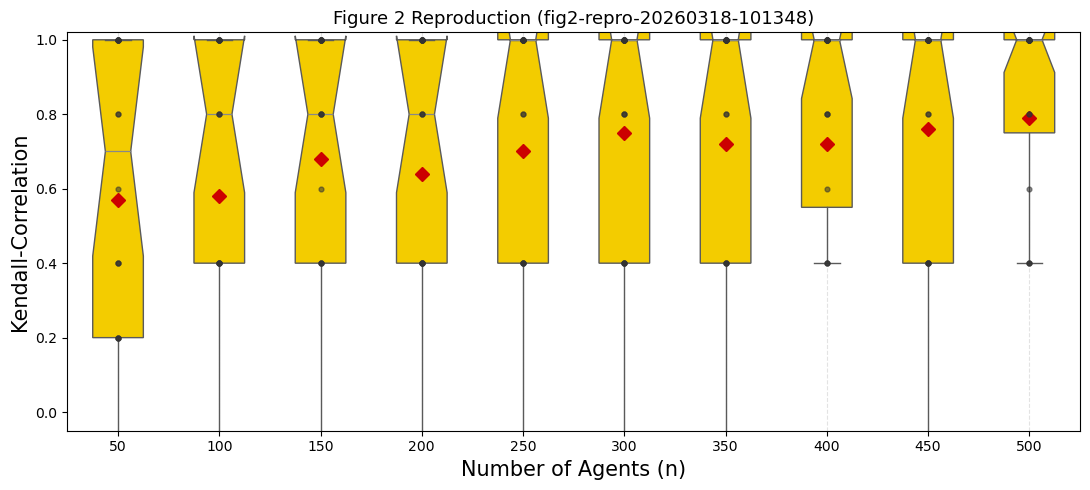

In [7]:
plot_data = [fig2_samples_by_count[n] for n in FIG2_AGENT_COUNTS]

plt.figure(figsize=(11, 5))
plt.boxplot(
    plot_data,
    tick_labels=[str(n) for n in FIG2_AGENT_COUNTS],
    notch=True,
    patch_artist=True,
    showfliers=True,
    showmeans=True,
    whis=1.5,
    medianprops={"color": "#888888", "linewidth": 0.9},
    meanprops={"marker": "D", "markerfacecolor": "#cc0000", "markeredgecolor": "#cc0000", "markersize": 7},
    boxprops={"facecolor": "#f3cc00", "edgecolor": "#5a5a5a", "linewidth": 1.0},
    whiskerprops={"color": "#5a5a5a", "linewidth": 1.0},
    capprops={"color": "#5a5a5a", "linewidth": 1.0},
    flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#888888", "markeredgecolor": "#666666", "alpha": 0.8},
)

for i, n in enumerate(FIG2_AGENT_COUNTS, start=1):
    vals = np.array(fig2_samples_by_count[n], dtype=float)
    xj = np.full(vals.shape, i, dtype=float)
    plt.scatter(xj, vals, s=12, color="#333333", alpha=0.55, zorder=3)

plt.xlabel("Number of Agents (n)", fontsize=15)
plt.ylabel("Kendall-Correlation", fontsize=15)
plt.ylim(-0.05, 1.02)
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.title(f"Figure 2 Reproduction ({RUN_DIR.name})", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# Figure 2 boxplot diagnostics
means = np.array([np.mean(fig2_samples_by_count[n]) for n in FIG2_AGENT_COUNTS], dtype=float)
stds = np.array([np.std(fig2_samples_by_count[n]) for n in FIG2_AGENT_COUNTS], dtype=float)

idx = np.arange(len(FIG2_AGENT_COUNTS), dtype=float)
mean_corr = float(np.corrcoef(idx, means)[0, 1]) if len(means) > 1 else float("nan")

print("Figure 2 mean Kendall by n:")
for n, m, s in zip(FIG2_AGENT_COUNTS, means, stds):
    print(f"n={n:>3}: mean={m:.4f}, std={s:.4f}")

print(f"\nTrend corr(index, mean): {mean_corr:.4f}")
if np.isfinite(mean_corr) and mean_corr > 0:
    print("Mean trend is positive overall.")
else:
    print("Mean trend is weak/noisy; artifact coverage may be too small.")

Figure 2 mean Kendall by n:
n= 50: mean=0.5700, std=0.4573
n=100: mean=0.5800, std=0.4854
n=150: mean=0.6800, std=0.4261
n=200: mean=0.6400, std=0.4587
n=250: mean=0.7000, std=0.4171
n=300: mean=0.7500, std=0.3626
n=350: mean=0.7200, std=0.4400
n=400: mean=0.7200, std=0.4308
n=450: mean=0.7600, std=0.3666
n=500: mean=0.7900, std=0.3872

Trend corr(index, mean): 0.9230
Mean trend is positive overall.


## Figure 2 Run Results Summary

This section presents the completed orchestration run metadata and aggregate summaries from the selected run folder.

In [5]:
metadata_path = RUN_DIR / "metadata.json"
asym_path = RUN_DIR / "aggregates" / "asymptotic.json"
timing_path = RUN_DIR / "aggregates" / "timing.json"

if not metadata_path.exists():
    raise FileNotFoundError(f"Missing metadata file: {metadata_path}")

meta = json.loads(metadata_path.read_text(encoding="utf-8"))
asym = json.loads(asym_path.read_text(encoding="utf-8")) if asym_path.exists() else {"summary": []}
timing = json.loads(timing_path.read_text(encoding="utf-8")) if timing_path.exists() else {"summary": {}}

print("Figure 2 Orchestration Run")
print("=" * 32)
print(f"Run folder      : {RUN_DIR}")
print(f"Started (UTC)   : {meta.get('started_at_utc')}")
print(f"Finished (UTC)  : {meta.get('finished_at_utc')}")
print(f"Subruns         : total={meta.get('n_total')}, success={meta.get('n_success')}, failed={meta.get('n_failed')}")

durations = [float(s.get("duration_seconds", 0.0)) for s in meta.get("subruns", [])]
if durations:
    print(f"Mean subrun sec : {sum(durations)/len(durations):.2f}")
    print(f"Min/Max subrun  : {min(durations):.2f} / {max(durations):.2f}")
    print(f"Total subrun min: {sum(durations)/60.0:.2f}")

print("\nAsymptotic aggregate summary (n_agents, count, mean, std):")
for row in asym.get("summary", []):
    print(
        f"n={row['n_agents']:>3} | count={row['count']:>2} | "
        f"mean={row['mean']:.4f} | std={row['std']:.4f}"
    )

timing_summary = timing.get("summary", {})
if timing_summary:
    print("\nTiming aggregate summary:")
    print(
        f"count={timing_summary.get('count')} | "
        f"mean={timing_summary.get('total_mean_seconds', 0.0):.2f}s | "
        f"std={timing_summary.get('total_std_seconds', 0.0):.2f}s | "
        f"min={timing_summary.get('total_min_seconds', 0.0):.2f}s | "
        f"max={timing_summary.get('total_max_seconds', 0.0):.2f}s"
    )

Figure 2 Orchestration Run
Run folder      : /home/lotanamit/grums4llms/results/repro/fig2-repro-20260318-101348
Started (UTC)   : 2026-03-18T10:13:48+00:00
Finished (UTC)  : 2026-03-18T11:31:14+00:00
Subruns         : total=20, success=20, failed=0
Mean subrun sec : 915.80
Min/Max subrun  : 548.04 / 2171.70
Total subrun min: 305.27

Asymptotic aggregate summary (n_agents, count, mean, std):
n= 50 | count=20 | mean=0.5700 | std=0.4573
n=100 | count=20 | mean=0.5800 | std=0.4854
n=150 | count=20 | mean=0.6800 | std=0.4261
n=200 | count=20 | mean=0.6400 | std=0.4587
n=250 | count=20 | mean=0.7000 | std=0.4171
n=300 | count=20 | mean=0.7500 | std=0.3626
n=350 | count=20 | mean=0.7200 | std=0.4400
n=400 | count=20 | mean=0.7200 | std=0.4308
n=450 | count=20 | mean=0.7600 | std=0.3666
n=500 | count=20 | mean=0.7900 | std=0.3872

Timing aggregate summary:
count=20 | mean=598.37s | std=37.44s | min=526.57s | max=660.42s


## Figure 3: Elicitation Criteria for Social Choice

The paper evaluates different elicitation criteria (random, D-opt, E-opt, social, personalized) by simulating interactive queries with agents.
The performance $y$-axis is the Kendall correlation between the ground truth social choice ranking and the estimated ranking over the number of agents elicited ($x$-axis).
Graphs are smoothed with a moving window length of 25.

### Read-Only Commands Used For Figure 3

```bash
# Dataset 1 Orchestration
python scripts/run_experiment_orchestration.py \
  --config configs/repro/figure3_dataset1_orchestration.yml

# Dataset 2 Orchestration
python scripts/run_experiment_orchestration.py \
  --config configs/repro/figure3_dataset2_orchestration.yml
```

In [ ]:
# Load Figure 3 artifacts from the latest run folders
def get_latest_fig3_run(dataset_name: str) -> Path | None:
    candidates = sorted([p for p in RESULTS_REPRO_DIR.glob(f"fig3-dataset{dataset_name}-repro-*") if p.is_dir()])
    return candidates[-1] if candidates else None

def load_criteria_summary(run_dir: Path) -> list[dict]:
    agg_path = run_dir / "aggregates" / "criteria.json"
    if agg_path.exists():
        import json
        payload = json.loads(agg_path.read_text(encoding="utf-8"))
        return payload.get("summary", [])
    return []

# Dataset 1
run_ds1 = get_latest_fig3_run("1")
summary_ds1 = load_criteria_summary(run_ds1) if run_ds1 else []

# Dataset 2
run_ds2 = get_latest_fig3_run("2")
summary_ds2 = load_criteria_summary(run_ds2) if run_ds2 else []

if not run_ds1 or not run_ds2:
    print("Warning: Figure 3 run folders for dataset 1 or 2 not found. Please run orchestration scripts first.")
else:
    print(f"Loaded Dataset 1: {run_ds1.name}")
    print(f"Loaded Dataset 2: {run_ds2.name}")

# Prepare plotting data
from collections import defaultdict
import pandas as pd

def parse_summary_to_pd(summary_list):
    series_by_crit = defaultdict(dict)
    for row in summary_list:
        crit = row["criterion"]
        rnd = int(row["rounds"])
        val = float(row["mean"])
        series_by_crit[crit][rnd] = val
    
    # Convert to DataFrame
    df = pd.DataFrame(series_by_crit)
    if not df.empty:
        df = df.sort_index()
        # Apply rolling window of 25
        df = df.rolling(window=25, min_periods=1).mean()
    return df

df_ds1 = parse_summary_to_pd(summary_ds1)
df_ds2 = parse_summary_to_pd(summary_ds2)


In [ ]:
# Plotting Figure 3
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Define line styles
style_map = {
    "random": {"color": "black", "linestyle": "-"},
    "social": {"color": "blue", "linestyle": "-."},
    "d_opt": {"color": "red", "linestyle": "--"},
    "e_opt": {"color": "green", "linestyle": ":"},
    "personalized": {"color": "purple", "linestyle": "-"}
}

label_map = {
    "random": "Random",
    "social": "Proposed (Social)",
    "d_opt": "D-optimality",
    "e_opt": "E-optimality",
    "personalized": "Personalized"
}

def plot_ax(ax, df, title):
    if df.empty:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center')
        return
    for crit in df.columns:
        if crit in style_map:
            ax.plot(df.index, df[crit], label=label_map[crit], **style_map[crit])
        else:
            ax.plot(df.index, df[crit], label=crit)
    
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Number of Agents", fontsize=12)
    ax.set_ylabel("Kendall Correlation", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.5)

plot_ax(ax1, df_ds1, "Dataset 1 (Small Social Component)")
plot_ax(ax2, df_ds2, "Dataset 2 (Large Social Component)")

if not df_ds1.empty or not df_ds2.empty:
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Figure 3: Synthetic Data & Social Choice\n(Smoothed with moving window length 25)", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()


## Other Figure Sections

> Add one section per experimental figure, and include a read-only command block at the top of that section.

> Notebook policy: no rerun options and no `subprocess` calls. Running all cells should only read artifacts from one selected orchestration run folder.

### Figure 1
- This is an informative flowchart in the paper, not an experiment.
- No rerun script command is required.

### Figure 3+ (Template)
- Add read-only command block first.
- Then add load/plot/diagnostics cells that only read existing JSON artifacts from a selected run folder.

```bash
python scripts/run_experiment_orchestration.py --config <figure_orchestration_config.yml>
```

## Presentation Notes
- Keep each section self-contained so figures can be executed independently.
- Keep each figure tied to one orchestration run folder for traceability.